In [1]:
!pip install opencv-python matplotlib

In [2]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files


In [3]:
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


Saving IMG_20260317_155749.jpg.jpeg to IMG_20260317_155749.jpg.jpeg


In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


In [5]:
edges = cv2.Canny(gray, 100, 200)


In [6]:
contours, hierarchy = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_contours = img_rgb.copy()
cv2.drawContours(img_contours, contours, -1, (255,0,0), 2)


array([[[214, 207, 201],
        [215, 208, 202],
        [215, 208, 202],
        ...,
        [178, 180, 175],
        [178, 180, 175],
        [178, 180, 175]],

       [[215, 208, 202],
        [215, 208, 202],
        [216, 209, 203],
        ...,
        [182, 184, 179],
        [181, 183, 178],
        [180, 182, 177]],

       [[215, 208, 202],
        [216, 209, 203],
        [217, 210, 204],
        ...,
        [185, 188, 181],
        [185, 188, 181],
        [184, 187, 180]],

       ...,

       [[232, 241, 250],
        [231, 240, 249],
        [231, 240, 247],
        ...,
        [161, 169, 190],
        [170, 176, 198],
        [183, 190, 209]],

       [[229, 239, 248],
        [229, 239, 248],
        [230, 241, 247],
        ...,
        [145, 153, 174],
        [162, 168, 190],
        [181, 187, 209]],

       [[227, 237, 246],
        [228, 238, 247],
        [230, 241, 247],
        ...,
        [142, 150, 173],
        [161, 167, 189],
        [182, 188, 210]]

In [7]:
import numpy as np
gray_float = np.float32(gray)
corners = cv2.cornerHarris(gray_float, 2, 3, 0.04)
corners = cv2.dilate(corners, None)
img_corners = img_rgb.copy()
img_corners[corners > 0.01 * corners.max()] = [0, 255, 0]


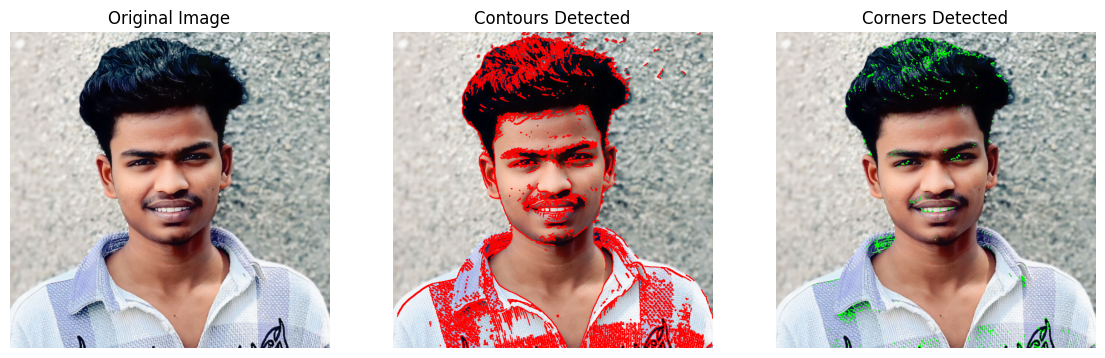

In [8]:
plt.figure(figsize=(14,6))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img_contours)
plt.title("Contours Detected")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img_corners)
plt.title("Corners Detected")
plt.axis("off")

plt.show()